# EDA: SBA Lending

Purpose: inspect national SBA 7(a) lending activity, lender concentration, county/sector coverage, and geography quality before blending with QCEW growth.

## Setup

Install if needed:

```bash
pip install pandas numpy matplotlib snowflake-connector-python
```

In [4]:

from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

DATABASE = "SMB_MARKET_INTELLIGENCE_DEV"
WAREHOUSE = os.getenv("SNOWFLAKE_WAREHOUSE", "COMPUTE_WH")
ROLE = os.getenv("SNOWFLAKE_ROLE", "ACCOUNTADMIN")
SNOWFLAKE_CONNECTION_NAME = os.getenv("SNOWFLAKE_CONNECTION_NAME", "smb_dev")
SNOWFLAKE_DATABASE = os.getenv("SNOWFLAKE_DATABASE", "SMB_MARKET_INTELLIGENCE_DEV")

def get_connection():
    import snowflake.connector

    return snowflake.connector.connect(
        connection_name=SNOWFLAKE_CONNECTION_NAME,
        database=SNOWFLAKE_DATABASE,
    )

def read_sql(query):
    with get_connection() as conn:
        return pd.read_sql(query, conn)

def show_basic_profile(df):
    display(df.head())
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns):,}")


## Load SBA lending aggregate

In [5]:

sba = read_sql("""
SELECT
    state_fips,
    state_abbr,
    state_name,
    county_fips,
    qcew_industry_code,
    sector_name,
    year,
    quarter,
    period_id,
    sba_loan_count,
    sba_gross_approval_amount,
    sba_initial_approval_amount,
    sba_current_approval_amount,
    sba_jobs_supported,
    active_lender_count,
    loans_missing_lender_name,
    avg_gross_loan_amount,
    top_lender_name,
    top_lender_loan_count,
    top_lender_gross_approval_amount,
    top_lender_share_by_count,
    top_lender_share_by_amount,
    lender_hhi_by_amount,
    lender_hhi_by_count,
    lender_concentration_tier,
    first_approval_date,
    latest_approval_date
FROM INT.INT_SBA_LENDING_COUNTY_INDUSTRY_QTR
""")

sba.columns = sba.columns.str.lower()
show_basic_profile(sba)


,state_fips,state_abbr,state_name,county_fips,qcew_industry_code,sector_name,year,quarter,period_id,sba_loan_count,...,top_lender_name,top_lender_loan_count,top_lender_gross_approval_amount,top_lender_share_by_count,top_lender_share_by_amount,lender_hhi_by_amount,lender_hhi_by_count,lender_concentration_tier,first_approval_date,latest_approval_date
0,53,WA,Washington,53009,62,Health Care and Social Assistance,2021,3,8087,24,...,Live Oak Banking Company,24,13320000.0,1.0,1.0,1.0,1.0,high_concentration,2021-09-20,2021-09-20
1,56,WY,Wyoming,56019,52,Finance and Insurance,2024,4,8100,24,...,Pathward National Association,24,6600000.0,1.0,1.0,1.0,1.0,high_concentration,2024-10-01,2024-10-01
2,08,CO,Colorado,08077,62,Health Care and Social Assistance,2023,1,8093,24,...,"22nd State Bank, A Division of 22nd State Bank...",24,35160000.0,1.0,1.0,1.0,1.0,high_concentration,2023-01-06,2023-01-06
3,42,PA,Pennsylvania,42077,72,Accommodation and Food Services,2023,3,8095,24,...,KeyBank National Association,24,960000.0,1.0,1.0,1.0,1.0,high_concentration,2023-07-27,2023-07-27
4,51,VA,Virginia,51710,72,Accommodation and Food Services,2020,2,8082,24,...,Truist Bank,24,7612800.0,1.0,1.0,1.0,1.0,high_concentration,2020-05-20,2020-05-20


Rows: 66,445
Columns: 27


## SBA activity over time

In [6]:

period_activity = (
    sba.groupby(["year", "quarter", "period_id"])
    .agg(
        rows=("county_fips", "size"),
        states=("state_fips", "nunique"),
        counties=("county_fips", "nunique"),
        sectors=("qcew_industry_code", "nunique"),
        loans=("sba_loan_count", "sum"),
        gross_approval_amount=("sba_gross_approval_amount", "sum"),
        active_lenders=("active_lender_count", "sum"),
    )
    .reset_index()
    .sort_values(["year", "quarter"])
)

display(period_activity.tail(12))


,year,quarter,period_id,rows,states,counties,sectors,loans,gross_approval_amount,active_lenders
14,2023,2,8094,2483,51,1096,6,172584,7.771892e+10,5203
15,2023,3,8095,2700,51,1150,6,204864,9.672040e+10,6176
16,2023,4,8096,2522,51,1093,6,179016,7.635030e+10,5487
17,2024,1,8097,2849,51,1182,6,211368,8.521547e+10,6421
18,2024,2,8098,2986,51,1235,6,232032,1.020053e+11,6987
19,2024,3,8099,3061,51,1238,6,252360,1.198362e+11,7504
20,2024,4,8100,3069,51,1277,6,250560,1.083376e+11,7572
21,2025,1,8101,3418,51,1378,6,291816,1.264736e+11,8690
22,2025,2,8102,2934,51,1226,6,231984,1.081928e+11,7011
23,2025,3,8103,2802,51,1192,6,209400,1.159797e+11,6636


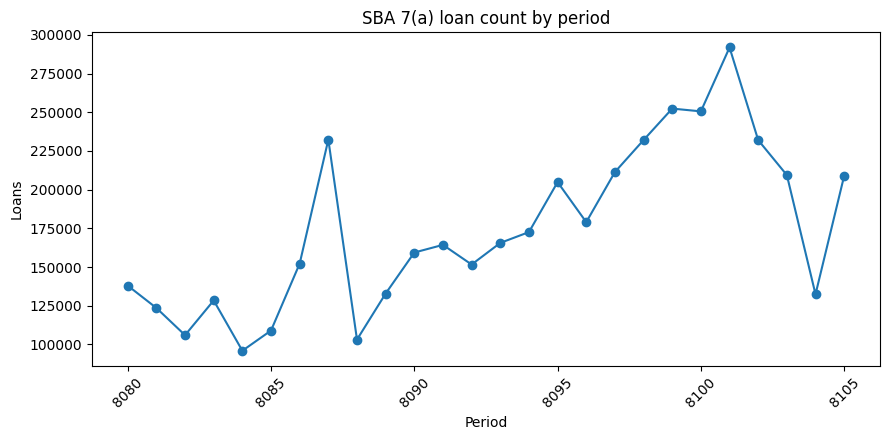

In [7]:

plt.figure(figsize=(9, 4.5))
plt.plot(period_activity["period_id"], period_activity["loans"], marker="o")
plt.title("SBA 7(a) loan count by period")
plt.xlabel("Period")
plt.ylabel("Loans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


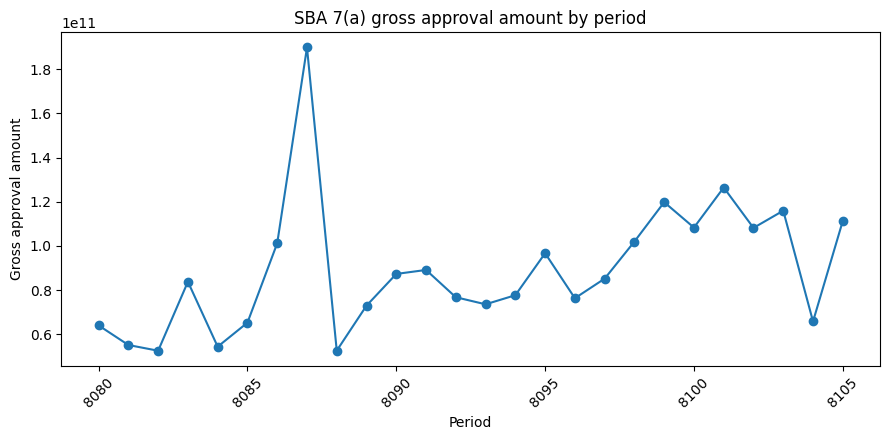

In [8]:

plt.figure(figsize=(9, 4.5))
plt.plot(period_activity["period_id"], period_activity["gross_approval_amount"], marker="o")
plt.title("SBA 7(a) gross approval amount by period")
plt.xlabel("Period")
plt.ylabel("Gross approval amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Sector mix

In [9]:

sector_activity = (
    sba.groupby(["qcew_industry_code", "sector_name"])
    .agg(
        rows=("county_fips", "size"),
        states=("state_fips", "nunique"),
        counties=("county_fips", "nunique"),
        loans=("sba_loan_count", "sum"),
        gross_approval_amount=("sba_gross_approval_amount", "sum"),
        active_lenders=("active_lender_count", "sum"),
        avg_hhi_amount=("lender_hhi_by_amount", "mean"),
        avg_top_lender_share_amount=("top_lender_share_by_amount", "mean"),
    )
    .reset_index()
    .sort_values("gross_approval_amount", ascending=False)
)

display(sector_activity)


,qcew_industry_code,sector_name,rows,states,counties,loans,gross_approval_amount,active_lenders,avg_hhi_amount,avg_top_lender_share_amount
5,72,Accommodation and Food Services,16333,51,2306,1103976,7.932344e+11,35828,0.809257,0.852182
4,62,Health Care and Social Assistance,11391,51,1700,826800,4.983291e+11,26392,0.797063,0.842525
0,23,Construction,15014,51,2018,1115088,4.129705e+11,31885,0.815006,0.858092
2,54,"Professional, Scientific, and Technical Services",10329,51,1597,834000,3.503815e+11,24966,0.795001,0.842107
3,56,Administrative and Support and Waste Management,9273,51,1542,498648,1.758310e+11,16388,0.847782,0.884065
1,52,Finance and Insurance,4105,51,962,161304,8.216217e+10,6046,0.894162,0.919497


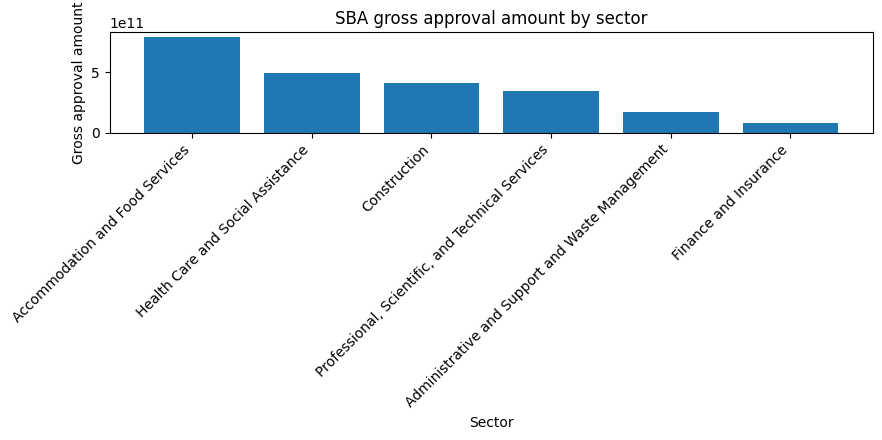

In [10]:

plt.figure(figsize=(9, 4.5))
plt.bar(sector_activity["sector_name"], sector_activity["gross_approval_amount"])
plt.title("SBA gross approval amount by sector")
plt.xlabel("Sector")
plt.ylabel("Gross approval amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Lender concentration

In [11]:

concentration = (
    sba.groupby("lender_concentration_tier")
    .agg(
        rows=("county_fips", "size"),
        loans=("sba_loan_count", "sum"),
        gross_approval_amount=("sba_gross_approval_amount", "sum"),
        avg_hhi_amount=("lender_hhi_by_amount", "mean"),
        avg_top_lender_share_amount=("top_lender_share_by_amount", "mean"),
    )
    .reset_index()
    .sort_values("gross_approval_amount", ascending=False)
)

display(concentration)


,lender_concentration_tier,rows,loans,gross_approval_amount,avg_hhi_amount,avg_top_lender_share_amount
1,high_concentration,64100,3590424,1.801356e+12,0.839880,0.879533
2,moderate_concentration,1849,585888,2.971593e+11,0.206090,0.317342
0,fragmented,496,363504,2.143938e+11,0.120285,0.211814


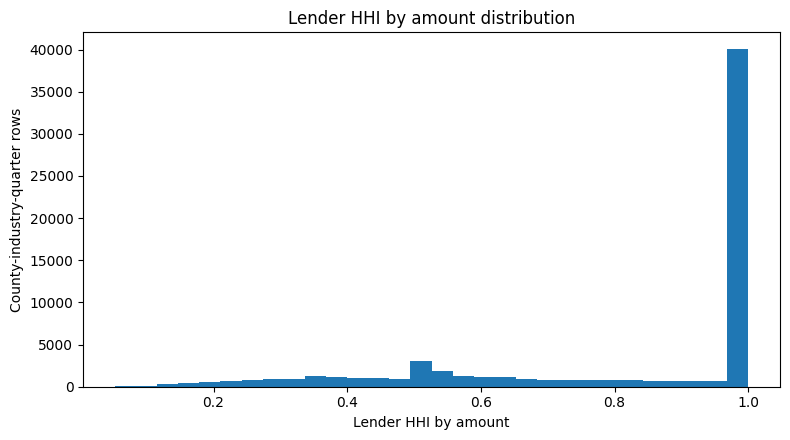

In [12]:

plt.figure(figsize=(8, 4.5))
plt.hist(sba["lender_hhi_by_amount"].dropna(), bins=30)
plt.title("Lender HHI by amount distribution")
plt.xlabel("Lender HHI by amount")
plt.ylabel("County-industry-quarter rows")
plt.tight_layout()
plt.show()


## Top lenders

In [13]:

top_lenders = (
    sba.dropna(subset=["top_lender_name"])
    .groupby("top_lender_name")
    .agg(
        rows=("county_fips", "size"),
        loans=("top_lender_loan_count", "sum"),
        gross_approval_amount=("top_lender_gross_approval_amount", "sum"),
        states=("state_fips", "nunique"),
        counties=("county_fips", "nunique"),
        sectors=("qcew_industry_code", "nunique"),
    )
    .reset_index()
    .sort_values("gross_approval_amount", ascending=False)
    .head(25)
)

display(top_lenders)


,top_lender_name,rows,loans,gross_approval_amount,states,counties,sectors
932,Live Oak Banking Company,2894,92472,1.420809e+11,50,847,6
1506,The Huntington National Bank,5916,284688,8.624266e+10,50,1025,6
719,GBank,550,14256,4.316452e+10,34,355,6
1056,"Newtek Bank, National Association",1902,61896,3.784600e+10,50,865,6
1231,"Readycap Lending, LLC",1607,44736,2.998768e+10,50,849,6
242,Byline Bank,664,20304,2.884466e+10,47,338,6
1588,"U.S. Bank, National Association",2576,81600,2.707651e+10,44,773,6
283,Celtic Bank Corporation,948,24168,2.523907e+10,50,596,6
1675,Wells Fargo Bank National Association,1560,42576,2.312745e+10,47,659,6
1057,"Newtek Small Business Finance, Inc.",878,24672,2.237755e+10,50,525,6


## Geography / staging quality flags

This reads staging flags to inspect county/state and sector match quality at loan level.

In [15]:

stg_quality = read_sql("""
SELECT
    has_state_fips,
    has_county_fips,
    county_state_fips_match,
    has_sector_mapping,
    COUNT(*) AS row_count
FROM STG.STG_SBA_7A_LOANS
GROUP BY
    has_state_fips,
    has_county_fips,
    county_state_fips_match,
    has_sector_mapping
ORDER BY row_count DESC
""")

stg_quality.columns = stg_quality.columns.str.lower()
display(stg_quality)


,has_state_fips,has_county_fips,county_state_fips_match,has_sector_mapping,row_count
0,True,True,True,True,4539816
1,True,False,False,True,125376


## Notes to capture

- Which sectors receive the most SBA support?
- Which county-industries have high growth but low SBA penetration after the mart join?
- Are lender concentration values interpretable and bounded?
- Are geography match rates acceptable for a portfolio project?